# Praktikum Visi Komputer - FFT dan Noise Filtering

Praktikum ini mencakup:
1. Analisis domain frekuensi menggunakan FFT
2. Penambahan berbagai jenis noise pada citra
3. Perbandingan filter untuk menghilangkan noise

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage
from scipy.ndimage import gaussian_filter, median_filter
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (15, 12)

Gambar berhasil dimuat dari citra.jpg


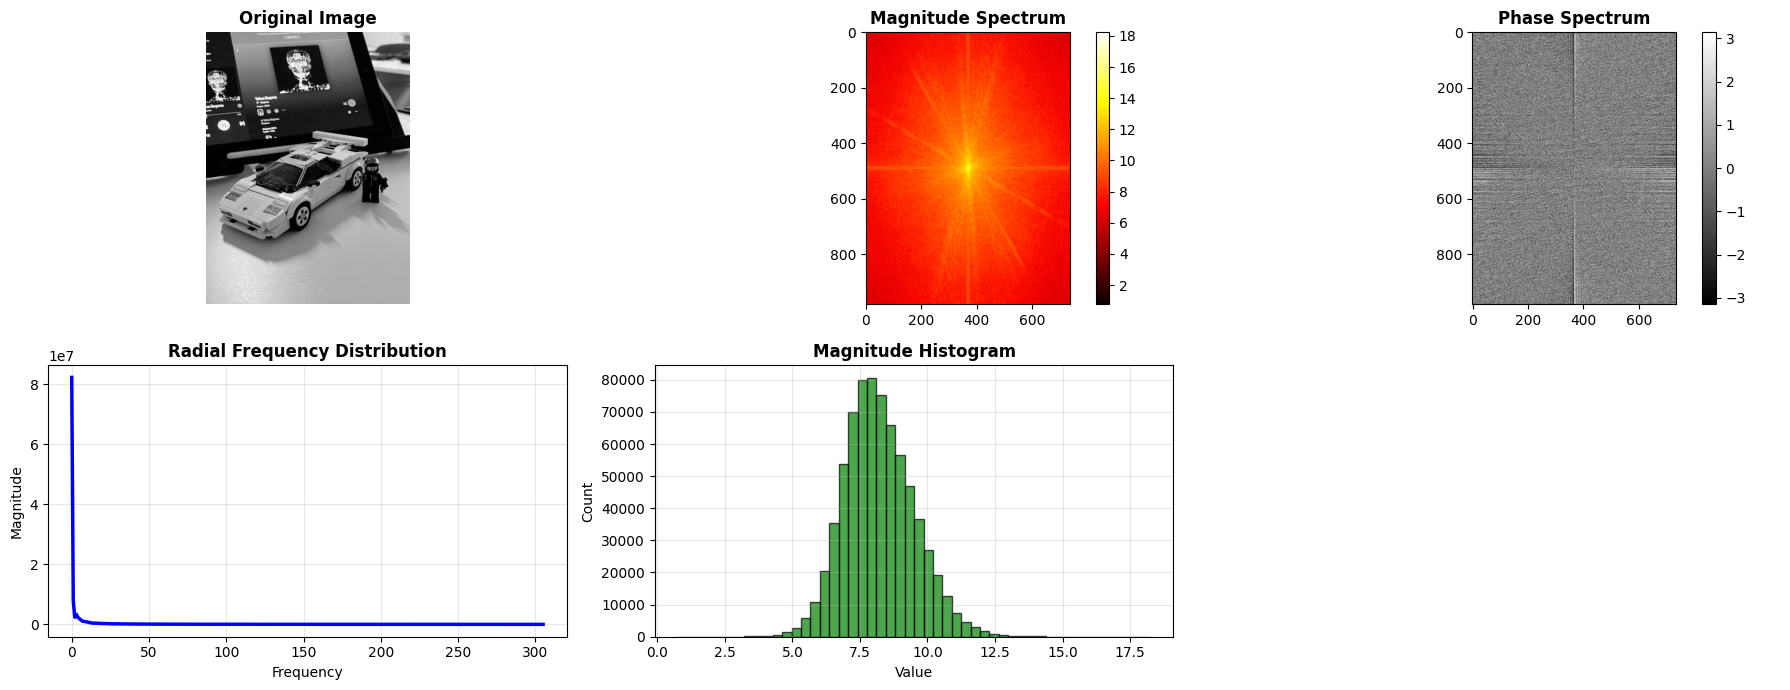

In [9]:
# BAGIAN 1 - Domain Frekuensi

# Load image from JPG file
img_path = 'citra.jpg'
img_fft = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img_fft is None:
    raise FileNotFoundError(f"Gambar tidak ditemukan: {img_path}")
print(f"Gambar berhasil dimuat dari {img_path}")

# FFT computation
fft_img = np.fft.fft2(img_fft)
fft_shift = np.fft.fftshift(fft_img)
magnitude_spectrum = np.log1p(np.abs(fft_shift))
phase_spectrum = np.angle(fft_shift)

# Frequency distribution analysis
def analyze_frequency_distribution(fft_shift):
    H, W = fft_shift.shape
    Y, X = np.ogrid[:H, :W]
    center_y, center_x = H//2, W//2
    distance = np.sqrt((Y - center_y)**2 + (X - center_x)**2).astype(int)
    max_distance = int(np.sqrt(H**2 + W**2) / 2)
    freq_bins = np.zeros(max_distance)
    for d in range(max_distance):
        mask = distance == d
        if np.sum(mask) > 0:
            freq_bins[d] = np.mean(np.abs(fft_shift[mask]))
    return freq_bins

freq_bins = analyze_frequency_distribution(fft_shift)

# Display all FFT results in one figure
fig = plt.figure(figsize=(18, 7))

# Original Image
ax1 = plt.subplot(2, 3, 1)
ax1.imshow(img_fft, cmap='gray')
ax1.set_title('Original Image', fontsize=12, fontweight='bold')
ax1.axis('off')

# Magnitude Spectrum
ax2 = plt.subplot(2, 3, 2)
im2 = ax2.imshow(magnitude_spectrum, cmap='hot')
ax2.set_title('Magnitude Spectrum', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=ax2)

# Phase Spectrum
ax3 = plt.subplot(2, 3, 3)
im3 = ax3.imshow(phase_spectrum, cmap='gray')
ax3.set_title('Phase Spectrum', fontsize=12, fontweight='bold')
plt.colorbar(im3, ax=ax3)

# Radial Frequency Distribution
ax4 = plt.subplot(2, 3, 4)
ax4.plot(freq_bins[:len(freq_bins)//2], 'b-', linewidth=2.5)
ax4.set_xlabel('Frequency', fontsize=10)
ax4.set_ylabel('Magnitude', fontsize=10)
ax4.set_title('Radial Frequency Distribution', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Magnitude Histogram
ax5 = plt.subplot(2, 3, 5)
ax5.hist(magnitude_spectrum.flatten(), bins=50, color='green', edgecolor='black', alpha=0.7)
ax5.set_xlabel('Value', fontsize=10)
ax5.set_ylabel('Count', fontsize=10)
ax5.set_title('Magnitude Histogram', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Empty space for better layout (optional)
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

plt.tight_layout()
plt.show()

Gambar berhasil dimuat dari citra.jpg


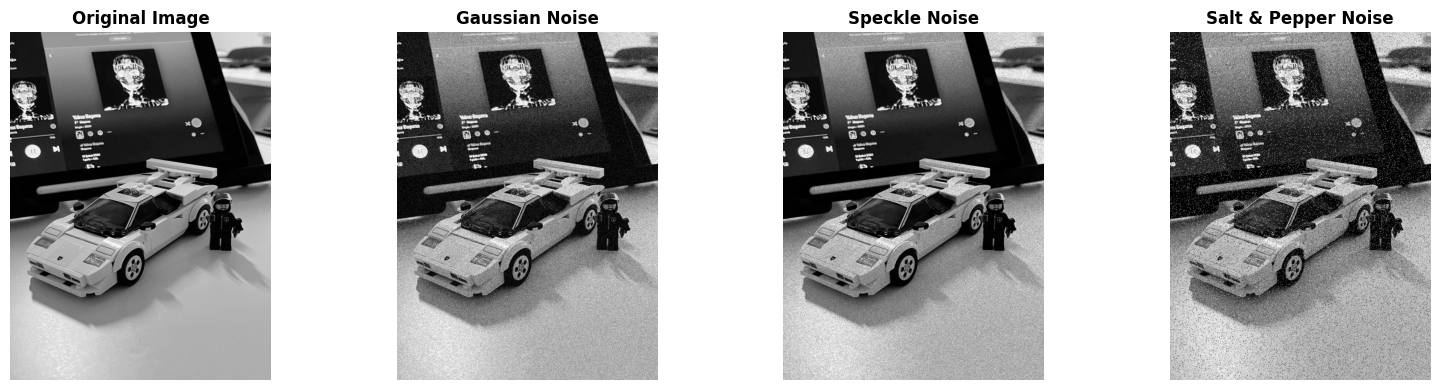

In [10]:
# BAGIAN 2 - Noise pada Citra

# Load image from JPG file
img_path = 'citra.jpg'
img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img_gray is None:
    raise FileNotFoundError(f"Gambar tidak ditemukan: {img_path}")
print(f"Gambar berhasil dimuat dari {img_path}")

original_image = img_gray.copy().astype(np.float32)

# Add noise functions
def add_gaussian_noise(image, mean=0, std=25):
    noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + noise
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

def add_speckle_noise(image, prob=0.1):
    speckle = np.random.normal(1, prob, image.shape)
    noisy_image = image * speckle
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(image, prob=0.05):
    noisy_image = image.copy()
    num_salt = np.ceil(prob/2 * image.size)
    coords_salt = [np.random.randint(0, i-1, int(num_salt)) for i in image.shape]
    noisy_image[tuple(coords_salt)] = 255
    num_pepper = np.ceil(prob/2 * image.size)
    coords_pepper = [np.random.randint(0, i-1, int(num_pepper)) for i in image.shape]
    noisy_image[tuple(coords_pepper)] = 0
    return noisy_image.astype(np.uint8)

# Generate noise
img_gaussian_noise = add_gaussian_noise(img_gray.astype(np.float32), mean=0, std=25)
img_speckle_noise = add_speckle_noise(img_gray.astype(np.float32), prob=0.15)
img_salt_pepper_noise = add_salt_pepper_noise(img_gray.astype(np.float32), prob=0.1)

# Display all noise types in one figure
fig = plt.figure(figsize=(16, 4))

ax1 = plt.subplot(1, 4, 1)
ax1.imshow(img_gray, cmap='gray')
ax1.set_title('Original Image', fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = plt.subplot(1, 4, 2)
ax2.imshow(img_gaussian_noise, cmap='gray')
ax2.set_title('Gaussian Noise', fontsize=12, fontweight='bold')
ax2.axis('off')

ax3 = plt.subplot(1, 4, 3)
ax3.imshow(img_speckle_noise, cmap='gray')
ax3.set_title('Speckle Noise', fontsize=12, fontweight='bold')
ax3.axis('off')

ax4 = plt.subplot(1, 4, 4)
ax4.imshow(img_salt_pepper_noise, cmap='gray')
ax4.set_title('Salt & Pepper Noise', fontsize=12, fontweight='bold')
ax4.axis('off')

plt.tight_layout()
plt.show()

Gaussian Noise:
Mean: 26.18, Gaussian: 27.94, Median: 27.35
Speckle Noise:
Mean: 26.69, Gaussian: 29.01, Median: 27.86
Salt & Pepper Noise:
Mean: 23.87, Gaussian: 23.68, Median: 29.17


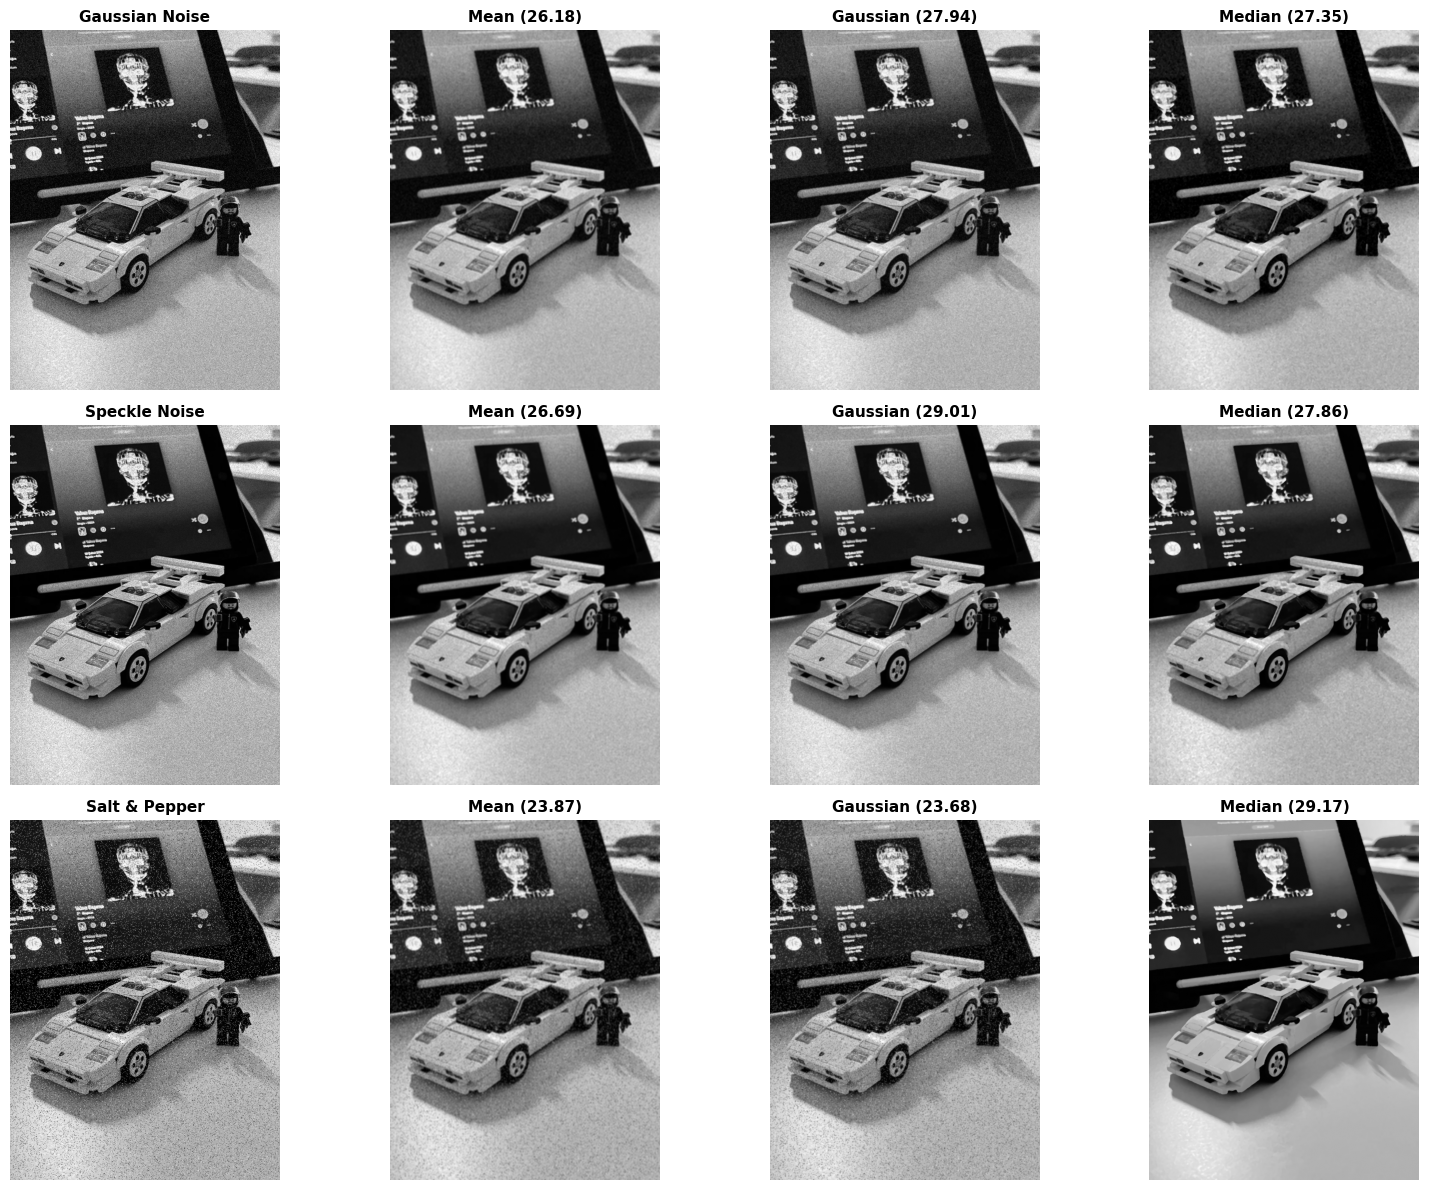


Results Summary:
    Noise Type    Filter       PSNR
0     Gaussian      Mean  26.184025
1     Gaussian  Gaussian  27.944439
2     Gaussian    Median  27.350657
3      Speckle      Mean  26.693642
4      Speckle  Gaussian  29.008989
5      Speckle    Median  27.864342
6  Salt&Pepper      Mean  23.872023
7  Salt&Pepper  Gaussian  23.683271
8  Salt&Pepper    Median  29.165928


In [11]:
# BAGIAN 3 - Penerapan Filtering pada Citra

# Filter functions
def apply_mean_filter(image, kernel_size=5):
    return cv2.blur(image, (kernel_size, kernel_size))

def apply_gaussian_filter(image, kernel_size=5, sigma=1.0):
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), sigma)

def apply_median_filter(image, kernel_size=5):
    return cv2.medianBlur(image, kernel_size)

# PSNR function
def calculate_psnr(original, filtered):
    if filtered.shape != original.shape:
        return 0
    mse = np.mean((original.astype(np.float32) - filtered.astype(np.float32))**2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

# Gaussian Noise
img_g_mean = apply_mean_filter(img_gaussian_noise)
img_g_gaussian = apply_gaussian_filter(img_gaussian_noise)
img_g_median = apply_median_filter(img_gaussian_noise)

psnr_g_mean = calculate_psnr(img_gray, img_g_mean)
psnr_g_gaussian = calculate_psnr(img_gray, img_g_gaussian)
psnr_g_median = calculate_psnr(img_gray, img_g_median)

# Speckle Noise
img_s_mean = apply_mean_filter(img_speckle_noise)
img_s_gaussian = apply_gaussian_filter(img_speckle_noise)
img_s_median = apply_median_filter(img_speckle_noise)

psnr_s_mean = calculate_psnr(img_gray, img_s_mean)
psnr_s_gaussian = calculate_psnr(img_gray, img_s_gaussian)
psnr_s_median = calculate_psnr(img_gray, img_s_median)

# Salt & Pepper Noise
img_sp_mean = apply_mean_filter(img_salt_pepper_noise)
img_sp_gaussian = apply_gaussian_filter(img_salt_pepper_noise)
img_sp_median = apply_median_filter(img_salt_pepper_noise)

psnr_sp_mean = calculate_psnr(img_gray, img_sp_mean)
psnr_sp_gaussian = calculate_psnr(img_gray, img_sp_gaussian)
psnr_sp_median = calculate_psnr(img_gray, img_sp_median)

# Display results for all noise types in separate rows
fig = plt.figure(figsize=(16, 12))

# Gaussian Noise Row
print("Gaussian Noise:")
print(f"Mean: {psnr_g_mean:.2f}, Gaussian: {psnr_g_gaussian:.2f}, Median: {psnr_g_median:.2f}")

ax1 = plt.subplot(3, 4, 1)
ax1.imshow(img_gaussian_noise, cmap='gray')
ax1.set_title('Gaussian Noise', fontsize=11, fontweight='bold')
ax1.axis('off')

ax2 = plt.subplot(3, 4, 2)
ax2.imshow(img_g_mean, cmap='gray')
ax2.set_title(f'Mean ({psnr_g_mean:.2f})', fontsize=11, fontweight='bold')
ax2.axis('off')

ax3 = plt.subplot(3, 4, 3)
ax3.imshow(img_g_gaussian, cmap='gray')
ax3.set_title(f'Gaussian ({psnr_g_gaussian:.2f})', fontsize=11, fontweight='bold')
ax3.axis('off')

ax4 = plt.subplot(3, 4, 4)
ax4.imshow(img_g_median, cmap='gray')
ax4.set_title(f'Median ({psnr_g_median:.2f})', fontsize=11, fontweight='bold')
ax4.axis('off')

# Speckle Noise Row
print("Speckle Noise:")
print(f"Mean: {psnr_s_mean:.2f}, Gaussian: {psnr_s_gaussian:.2f}, Median: {psnr_s_median:.2f}")

ax5 = plt.subplot(3, 4, 5)
ax5.imshow(img_speckle_noise, cmap='gray')
ax5.set_title('Speckle Noise', fontsize=11, fontweight='bold')
ax5.axis('off')

ax6 = plt.subplot(3, 4, 6)
ax6.imshow(img_s_mean, cmap='gray')
ax6.set_title(f'Mean ({psnr_s_mean:.2f})', fontsize=11, fontweight='bold')
ax6.axis('off')

ax7 = plt.subplot(3, 4, 7)
ax7.imshow(img_s_gaussian, cmap='gray')
ax7.set_title(f'Gaussian ({psnr_s_gaussian:.2f})', fontsize=11, fontweight='bold')
ax7.axis('off')

ax8 = plt.subplot(3, 4, 8)
ax8.imshow(img_s_median, cmap='gray')
ax8.set_title(f'Median ({psnr_s_median:.2f})', fontsize=11, fontweight='bold')
ax8.axis('off')

# Salt & Pepper Noise Row
print("Salt & Pepper Noise:")
print(f"Mean: {psnr_sp_mean:.2f}, Gaussian: {psnr_sp_gaussian:.2f}, Median: {psnr_sp_median:.2f}")

ax9 = plt.subplot(3, 4, 9)
ax9.imshow(img_salt_pepper_noise, cmap='gray')
ax9.set_title('Salt & Pepper', fontsize=11, fontweight='bold')
ax9.axis('off')

ax10 = plt.subplot(3, 4, 10)
ax10.imshow(img_sp_mean, cmap='gray')
ax10.set_title(f'Mean ({psnr_sp_mean:.2f})', fontsize=11, fontweight='bold')
ax10.axis('off')

ax11 = plt.subplot(3, 4, 11)
ax11.imshow(img_sp_gaussian, cmap='gray')
ax11.set_title(f'Gaussian ({psnr_sp_gaussian:.2f})', fontsize=11, fontweight='bold')
ax11.axis('off')

ax12 = plt.subplot(3, 4, 12)
ax12.imshow(img_sp_median, cmap='gray')
ax12.set_title(f'Median ({psnr_sp_median:.2f})', fontsize=11, fontweight='bold')
ax12.axis('off')

plt.tight_layout()
plt.show()

# Results
print("\nResults Summary:")
results = pd.DataFrame({
    'Noise Type': ['Gaussian', 'Gaussian', 'Gaussian', 'Speckle', 'Speckle', 'Speckle', 'Salt&Pepper', 'Salt&Pepper', 'Salt&Pepper'],
    'Filter': ['Mean', 'Gaussian', 'Median', 'Mean', 'Gaussian', 'Median', 'Mean', 'Gaussian', 'Median'],
    'PSNR': [psnr_g_mean, psnr_g_gaussian, psnr_g_median, psnr_s_mean, psnr_s_gaussian, psnr_s_median, psnr_sp_mean, psnr_sp_gaussian, psnr_sp_median]
})
print(results)